# Regressão:

Problemas de regressão tratam-se de situção em que se deseja estimar o valor de uma varíavel continua a partir de um conjunto de métricas. 



**Agloritmos do experimento:**

* Decision Tree
* Random Forest
* Linear Regression
* Knn Regression
* Lr lasso
* Lr ridge
* Lr Elastic Net
* Polinomial Regression
* XGBoost

In [5]:
from sklearn.tree           import DecisionTreeRegressor      as dtr 
from sklearn.ensemble       import RandomForestRegressor      as rfr 
from sklearn.linear_model   import LinearRegression           as lr 
from sklearn.linear_model   import Ridge                      as rg 
from sklearn.linear_model   import Lasso                      as ls
from sklearn.linear_model   import ElasticNet                 as en 
from sklearn.neighbors      import KNeighborsRegressor        as knr
from sklearn.metrics        import mean_absolute_error        as mae
from sklearn.metrics        import root_mean_squared_error    as rmse
from sklearn.metrics        import r2_score                   as r2
from sklearn.metrics        import mean_absolute_percentage_error as mape
from sklearn.preprocessing  import PolynomialFeatures            as pf

#from sklearn.ensemble     import GradientBoostingRegressor as gbr

# Dataset: 


In [6]:
import pandas as pd
import sys 
import numpy as np 

sys.path.append('../../libs/src')

from data_utils import normalizer   


X_dataset = {}
X_dataset['training'] = pd.read_csv('../data/X_training.csv')
X_dataset['test'] = pd.read_csv('../data/X_test.csv') 
X_dataset['validation'] = pd.read_csv('../data/X_validation.csv')

y_dataset = {}
y_dataset['training'] = pd.read_csv('../data/y_training.csv')
y_dataset['test'] = pd.read_csv('../data/y_test.csv') 
y_dataset['validation'] = pd.read_csv('../data/y_validation.csv')

y_log_dataset = {}
y_log_dataset['training'] = y_dataset['training'].apply(lambda x: np.log1p(x))
y_log_dataset['test'] = y_dataset['test'].apply(lambda x: np.log1p(x))
y_log_dataset['validation'] = y_dataset['validation'].apply(lambda x: np.log1p(x)) 

In [7]:
X_normalized_dataset = {}
y_normalized_dataset = {}
normalizador = normalizer(X_dataset['training'],
                          strategy = 'minMaxScaller')
for k in X_dataset.keys():
    X_normalized_dataset[k] = normalizador.getDfcolumnNormalized(X_dataset[k])



#### Normalizacao de y depende de avaliação da sua distribuição

In [8]:
y_dataset['training'].describe()

,song_popularity
count,10547.000000
mean,53.046961
std,21.864535
min,0.100000
25%,40.000000
50%,56.000000
75%,69.000000
max,100.000000


array([[<Axes: title={'center': 'song_popularity'}>]], dtype=object)

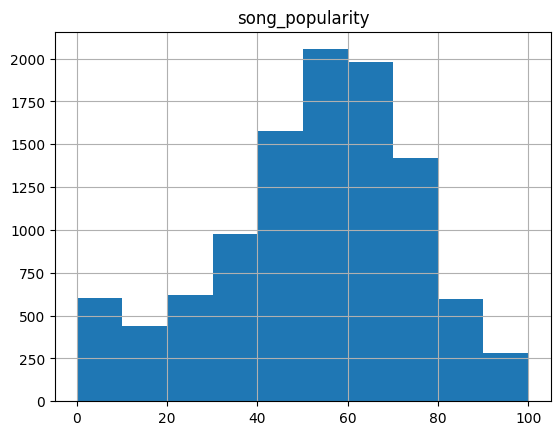

In [9]:
y_dataset['training'].hist()

# Utils

In [40]:
from typing import Literal
import matplotlib.pyplot as plt


class regressor():
    
    def __init__(self,
                 x_dataset,
                 y_dataset,
                 modelName   : str, 
                 modelParams : dict = 'default',
                 verbose     : bool = False):
        
        self.x_dataset   = x_dataset
        self.y_dataset   = y_dataset
        self.modelParams = modelParams
        self.modelName   = modelName
        self.verbose     = verbose
        
    def getBestModel(
                    self,
                    metricEvaluated : Literal['mae','rmse','r2','mape']='mae') -> dict: 
        
        '''
        args: results : dict like {
            ['mae'       : {'training':..., 'test':..., 'validation':...},
            ..., 
            'modelName' : modelName
            ]}
        '''
        eval_metrics = []
        
        for item in self.model_results:
            eval_metrics.append(item[metricEvaluated]['validation']) 

        best_index = eval_metrics.index(min(eval_metrics))

        return self.model_results[best_index] 
        

    def getModelPredictions(self,
                            model):

        y_predicted = {}
        y_predicted['training']     = model.predict(self.x_dataset['training'])
        y_predicted['test']         = model.predict(self.x_dataset['test'])
        y_predicted['validation']   = model.predict(self.x_dataset['validation'])
        
        return y_predicted
    

    def getSortedDataset(self,y_predicted, y_true):
        
        df = pd.DataFrame(y_predicted, columns=['predicted'])
        df['true'] = y_true.reset_index(drop=True)
        df = df.sort_values(by='true').reset_index(drop=True)
        
        return df


    def drawPlots(self, 
                y_predicted):
        
        # generate a subplots for training, test and validation datasets, each once needs to be a line  
        
        fig, ax = plt.subplots(3, 1, figsize=(18,9))
        
        sorted_training = self.getSortedDataset(y_predicted['training'],   self.y_dataset['training'])
        sorted_valid    = self.getSortedDataset(y_predicted['validation'], self.y_dataset['validation'])
        sorted_test     = self.getSortedDataset(y_predicted['test'],       self.y_dataset['test'])


        ax[0].scatter(y = sorted_training['true'].values, x = [x for x in range(0,len(sorted_training))], label='True values', color='blue')
        ax[0].plot(sorted_training['predicted'], label='Predicted values', color = 'red')
        ax[0].set_title('Training dataset')
        ax[0].legend()

        ax[1].scatter(y = sorted_test['true'].values, x = [x for x in range(0,len(sorted_test))], label='True values', color='blue')
        ax[1].plot(sorted_test['predicted'], label='Predicted values', color = 'red')
        ax[1].set_title('Training dataset')
        ax[1].legend()


        ax[2].scatter(y = sorted_valid['true'].values, x = [x for x in range(0,len(sorted_valid))], label='True values', color='blue')
        ax[2].plot(sorted_valid['predicted'], label='Predicted values', color = 'red')
        ax[2].set_title('Validation dataset')
        ax[2].legend()
        

    def compute_metrics(self, 
                        y_predicted : dict):
    
        '''
        
        Compute regression metrics: MAE, RMSE, R2, MAPE for training, test and validation datasets.
        args:
            y_dataset       : dict with true values for 'training', 'test' and 'validation' datasets
            y_predicted    : dict with predicted values for 'training', 'test'
        
        '''
        
        mae_results = {
            'training'  : mae(self.y_dataset['training'],  y_predicted['training']),
            'test'      : mae(self.y_dataset['test'],      y_predicted['test']),
            'validation': mae(self.y_dataset['validation'],     y_predicted['validation'])
        }
        rmse_results = {
            'training'  : rmse(self.y_dataset['training'],  y_predicted['training']),
            'test'      : rmse(self.y_dataset['test'],      y_predicted['test']),
            'validation': rmse(self.y_dataset['validation'],     y_predicted['validation'])
        }

        r2_results = {
            'training'  : r2(self.y_dataset['training'],  y_predicted['training']),
            'test'      : r2(self.y_dataset['test'],      y_predicted['test']),
            'validation': r2(self.y_dataset['validation'],     y_predicted['validation'])
        }

        mape_results = {
            'training'  : mape(self.y_dataset['training'],  y_predicted['training']),
            'test'      : mape(self.y_dataset['test'],      y_predicted['test']),
            'validation': mape(self.y_dataset['validation'],     y_predicted['validation'])
        }


        if self.verbose:
            print('--- Training ---')
            print('MAE  :', mae_results['training'])
            print('RMSE :', rmse_results['training'])
            print('R2   :', r2_results['training'])
            print('MAPE :', mape_results['training'])   

            print('--- Test ---')

            print('MAE  :', mae_results['test'])
            print('RMSE :', rmse_results['test'])
            print('R2   :', r2_results['test'])
            print('MAPE :', mape_results['test'])

            print('--- Validation ---')
            print('MAE  :', mae_results['validation'])
            print('RMSE :', rmse_results['validation'])
            print('R2   :', r2_results['validation'])
            print('MAPE :', mape_results['validation']) 


        results = {
            'mae'       : mae_results,
            'rmse'      : rmse_results,
            'r2'        : r2_results,
            'mape'      : mape_results,
            'modelName' : self.modelName,
            'modelParams' : str(self.modelParams)
        }

        return results



# Treinando os modelos

## 2.1 - Modelos Lineares

### 2.1.1 - Regressão linear

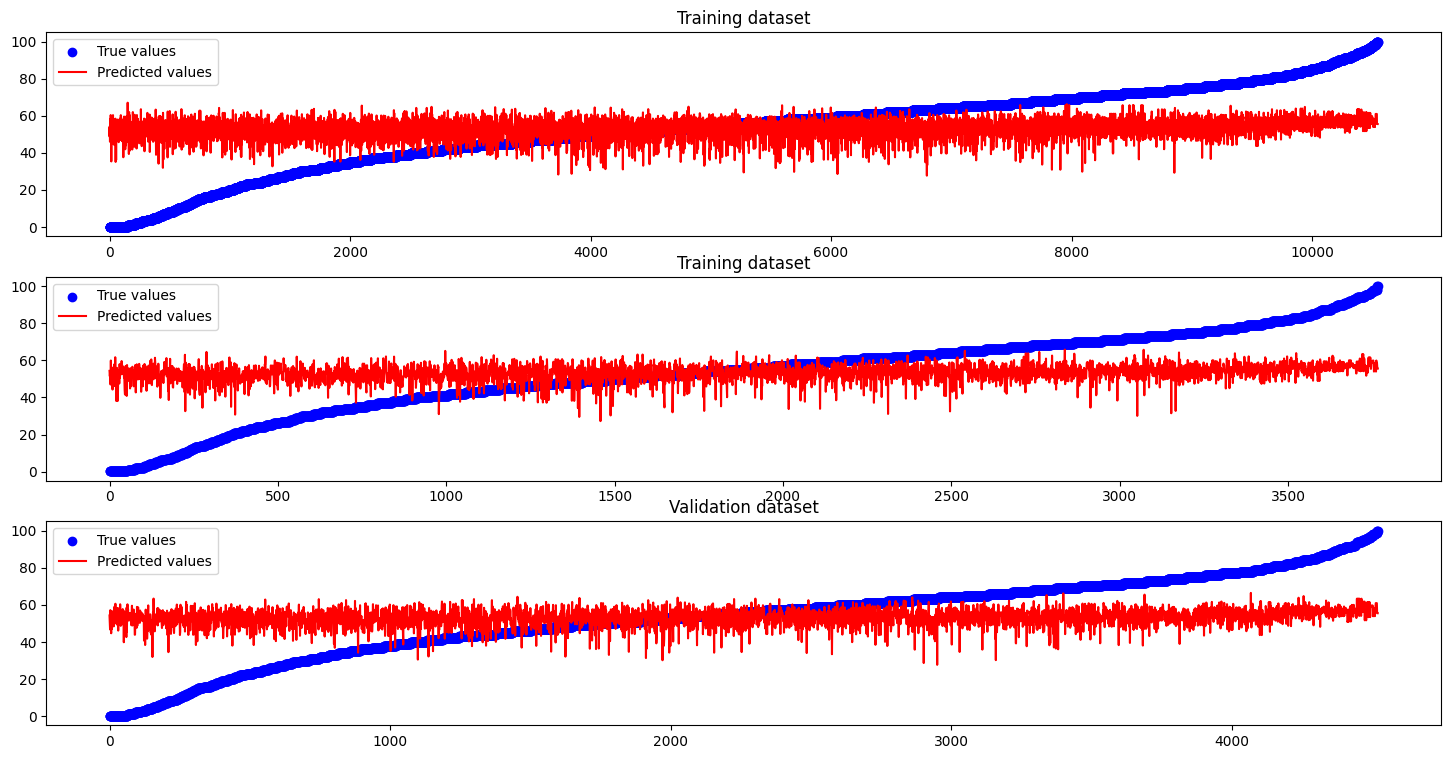

In [41]:
class linearRegressionModel(regressor):

    
    def __init__(self,
                 x_dataset : dict, 
                 y_dataset : dict, 
                 mondelName : str   = 'Linear Regression',
                 modelParams : dict = 'default'):
        
        super().__init__(x_dataset      = x_dataset, 
                         y_dataset      = y_dataset, 
                         modelName      = mondelName,
                         modelParams    = modelParams,
                         verbose=False
                         )
        
        

    def fitAndEvaluate(self):

        linearRegressor = lr()
        linearRegressor.fit(self.x_dataset['training'], 
                            self.y_dataset['training'])

        lr_predictions  = self.getModelPredictions(linearRegressor)      

        self.model_results      = self.compute_metrics(lr_predictions)

        self.model_results['model'] = 'Linear Regression'

        self.drawPlots(lr_predictions)
        

linearRegression = linearRegressionModel(X_normalized_dataset, y_dataset) 
linearRegression.fitAndEvaluate()


### 2.1.2 Regressão linear l1 - lasso 

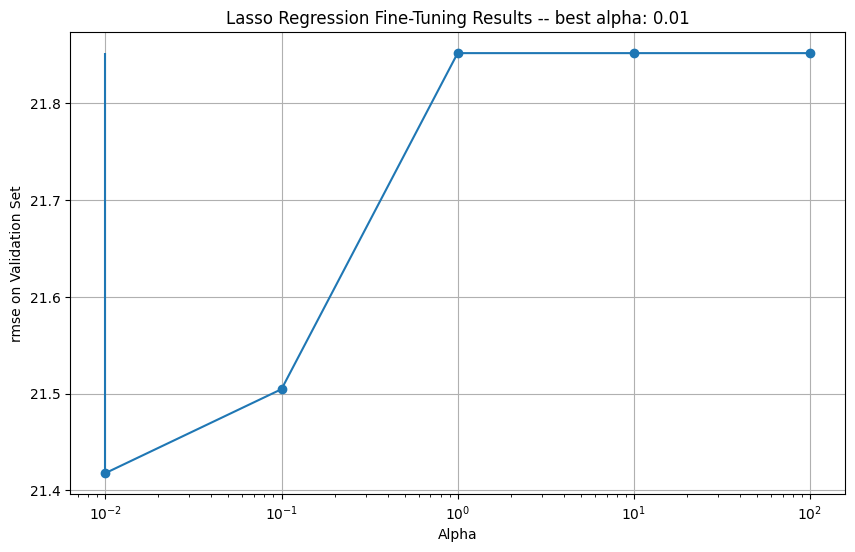

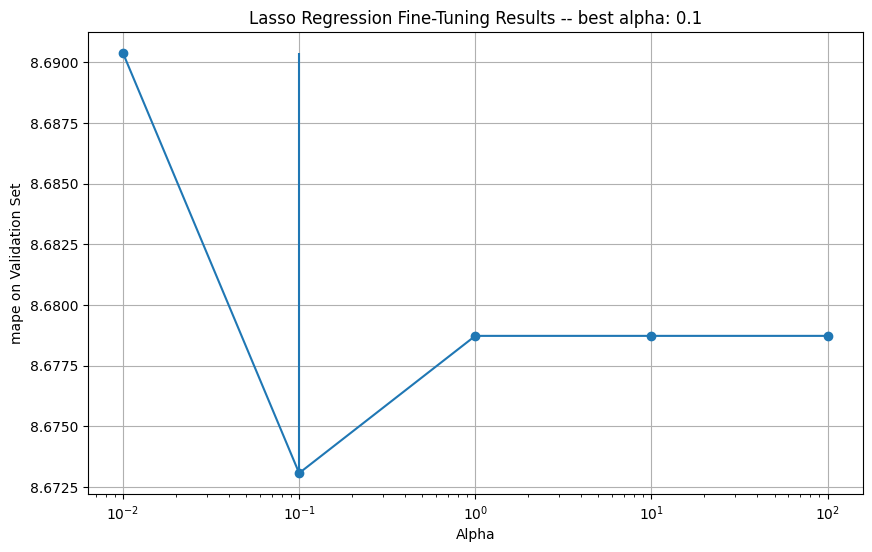

In [44]:
class linearRegressionLassoModel(regressor):

    
    def __init__(self,
                 x_dataset : dict, 
                 y_dataset : dict, 
                 modelName : str   = 'Lasso Linear Regression',
                 modelParams : dict = 'default',
                 verbose : bool = False):
        

        super().__init__(x_dataset      = x_dataset, 
                         y_dataset      = y_dataset, 
                         modelName      = modelName,
                         modelParams    = modelParams,
                         verbose       = verbose
                         )
        
        self.model_results = []

        
    def fineTunning(self,
                    metricEvaluated : Literal['mae','rmse','r2','mape']='mae'):

        for alpha in self.modelParams['alpha']:
            
            linearRegressor = ls(alpha = alpha)
            linearRegressor.fit(self.x_dataset['training'], 
                                self.y_dataset['training'])

            lr_predictions  = self.getModelPredictions(linearRegressor)      

            model_results              = self.compute_metrics(lr_predictions)
            model_results['parameter'] = alpha
            model_results['model']     = 'Linear Regression'

            self.model_results.append(model_results)
        
        self.best_model = self.getBestModel(metricEvaluated=metricEvaluated)
        
        

    def drawFineTunningResults(self,
                               metricEvaluated : Literal['mae','rmse','r2','mape']='mae'):

        alphas = [item['parameter'] for item in self.model_results]
        loss   = [item[metricEvaluated]['validation'] for item in self.model_results]
        bestAlpha = self.getBestModel(metricEvaluated=metricEvaluated)['parameter']

        plt.figure(figsize=(10,6))
        plt.plot(alphas, loss, marker='o')
        plt.xscale('log')
        plt.xlabel('Alpha')
        plt.ylabel(f'{metricEvaluated} on Validation Set')

        plt.title('Lasso Regression Fine-Tuning Results -- best alpha: {}'.format(bestAlpha))
        plt.vlines(x = bestAlpha,
                   ymin = min(loss),
                   ymax = max(loss))       
         
        plt.grid(True)
        plt.show()
        


parameters = {
    'alpha' : [0.01, 0.1, 1.0, 10.0, 100.0]
}

lasso = linearRegressionLassoModel(X_normalized_dataset, 
                                   y_dataset, 
                                   modelParams=parameters)
 
lasso.fineTunning()

lasso.drawFineTunningResults(metricEvaluated='rmse')
lasso.drawFineTunningResults(metricEvaluated='mape')




--- Training ---
MAE  : 17.209381331595
RMSE : 21.654642211964887
R2   : 0.01901420885675087
MAPE : 8.710433369767896
--- Test ---
MAE  : 17.338646166088843
RMSE : 21.825630997980987
R2   : 0.02165287799611515
MAPE : 8.615066687473998
--- Validation ---
MAE  : 17.039753759960327
RMSE : 21.41137645841414
R2   : 0.03992483038154071
MAPE : 8.682541883735295


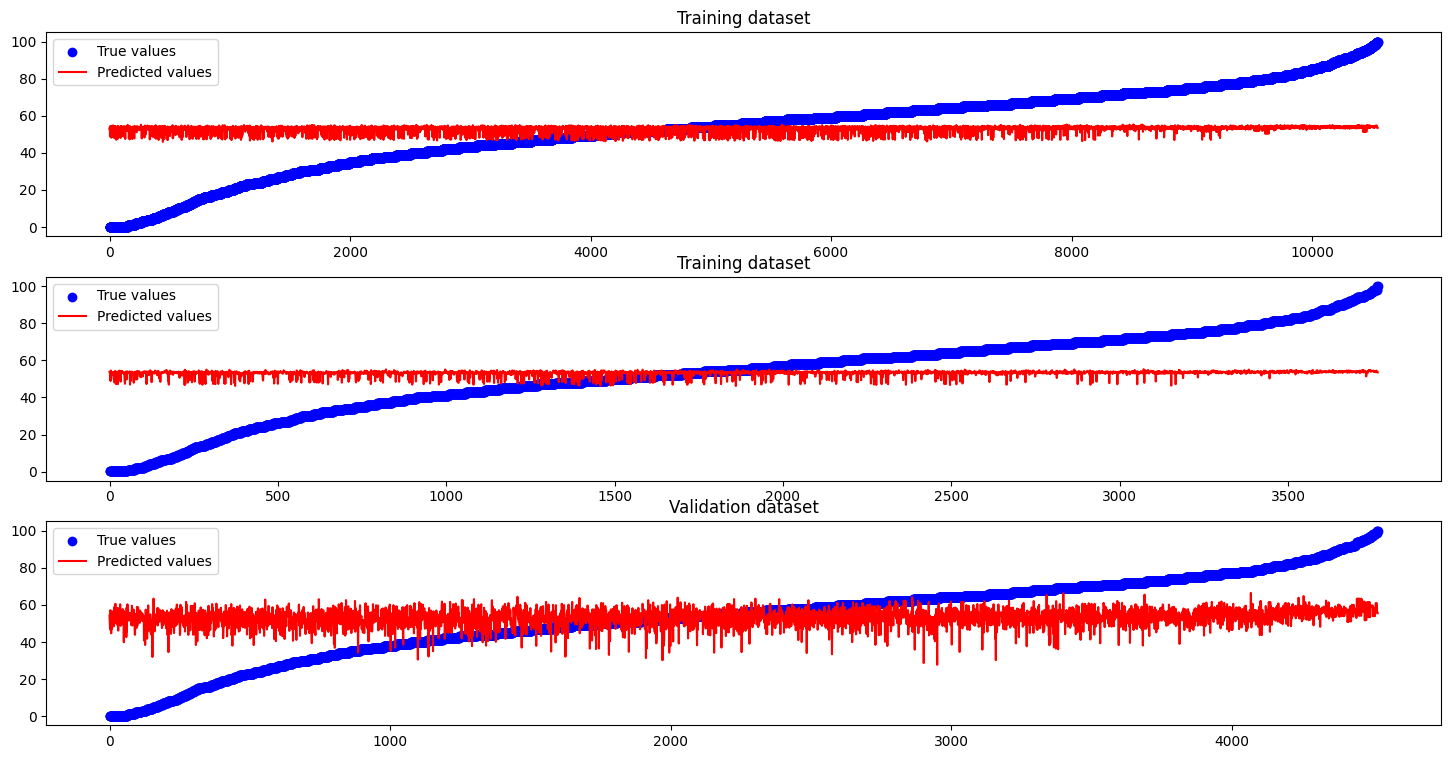

In [91]:
lasso = ls(alpha=0.3)
lasso.fit(X_normalized_dataset['training'], 
          y_dataset['training'])

y_predicted_training = lasso.predict(X_normalized_dataset['training'])
y_predicted_test = lasso.predict(X_normalized_dataset['test'])
y_predicted_training = lasso.predict(X_normalized_dataset['training'])

lasso_predictions = {
    'training' : y_predicted_training,
    'test'     : y_predicted_test,
    'validation'    : y_predicted_valid
}

lassoResults = compute_metrics(y_dataset,  
                               lasso_predictions,   
                    modelName = 'Lasso Regression'
                )

drawPlots(y_dataset, lasso_predictions)

 



### 2.1.3 - Regressão Linear l2 - ridge

--- Training ---
MAE  : 16.998423499265435
RMSE : 21.354069647950812
R2   : 0.046057930886195586
MAPE : 8.653388608963338
--- Test ---
MAE  : 17.130139091594955
RMSE : 21.481050248523374
R2   : 0.05230109892698165
MAPE : 8.521764720020727
--- Validation ---
MAE  : 17.039753759960327
RMSE : 21.41137645841414
R2   : 0.03992483038154071
MAPE : 8.682541883735295


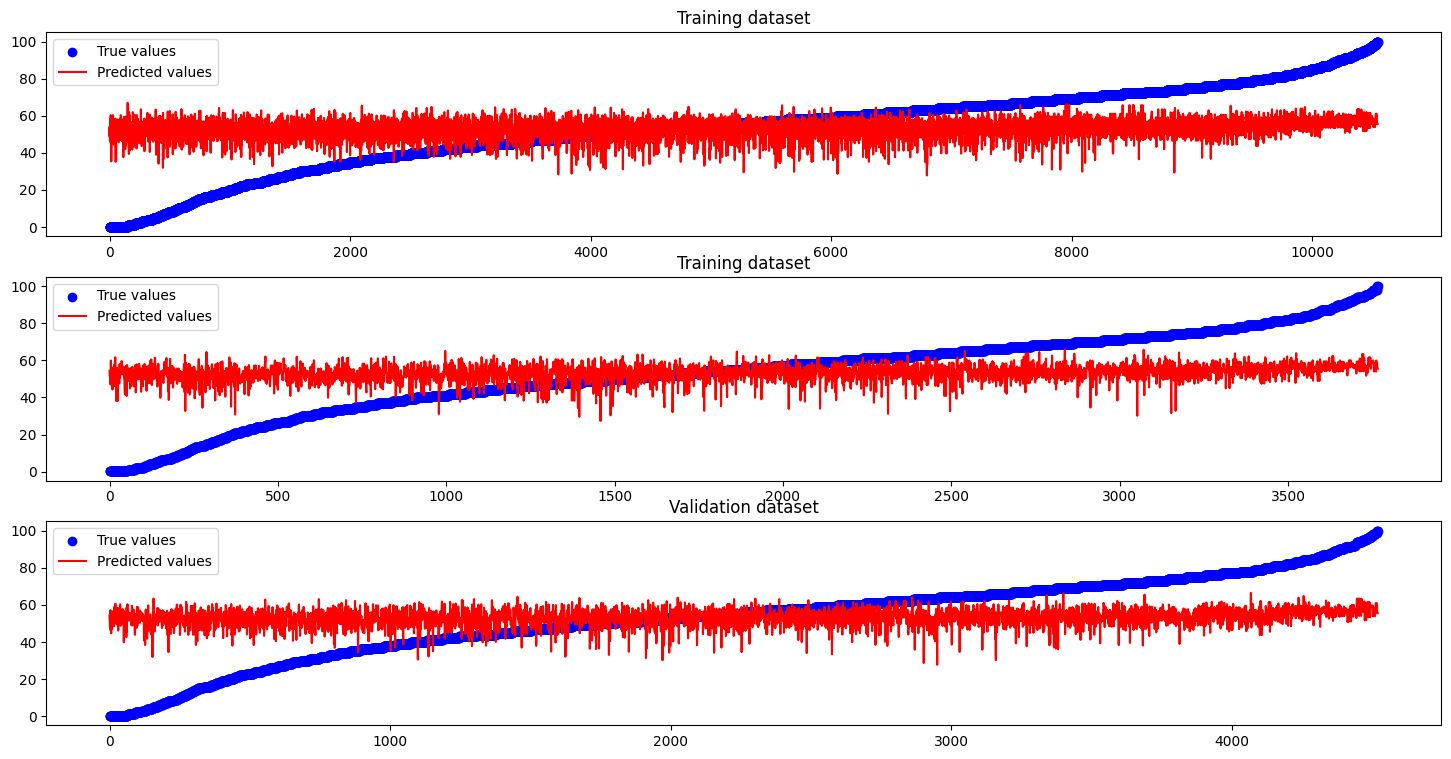

In [93]:
ridge = rg(alpha=0.3)
ridge.fit(X_normalized_dataset['training'], 
          y_dataset['training'])

y_predicted_training = ridge.predict(X_normalized_dataset['training'])
y_predicted_test = ridge.predict(X_normalized_dataset['test'])
y_predicted_training = ridge.predict(X_normalized_dataset['training'])

ridge_predictions = {
    'training'      : y_predicted_training,
    'test'          : y_predicted_test,
    'validation'    : y_predicted_valid
}

ridgeResults = compute_metrics(y_dataset, 
                                ridge_predictions,
                    modelName = 'Ridge Regression'
                )

 
drawPlots(y_dataset, ridge_predictions)


### 2.1.4 - Regressão Linear l1 + l2 - elasticNet

In [46]:
elasticNet = en(l1_ratio=0.3)
elasticNet.fit(X_normalized_dataset['training'], 
               y_dataset['training'])

y_predicted_training    = elasticNet.predict(X_normalized_dataset['training'])
y_predicted_test        = elasticNet.predict(X_normalized_dataset['test'])
y_predicted_valid       = elasticNet.predict(X_normalized_dataset['validation'])

elasticNetResults       = compute_metrics(y_dataset, 
                            {'training' : y_predicted_training,
                             'test'     : y_predicted_test,
                             'validation'    : y_predicted_valid
                            },
                            modelName = 'Elastic Net Regression'
                    )



--- Training ---
MAE  : 17.350640277304016
RMSE : 21.846601417268186
R2   : 0.0015450775914022108
MAPE : 8.741098462707908
--- Test ---
MAE  : 17.53275144340287
RMSE : 22.04752874761076
R2   : 0.0016583495420343652
MAPE : 8.708978154411797
--- Validation ---
MAE  : 17.337936593846145
RMSE : 21.836888390436744
R2   : 0.0013861806991620762
MAPE : 8.677119140651714


## 2.2 Modelos mais complexos (lineares ou não)

### 2.2.1 - Decision Tree

--- Training ---
MAE  : 0.2320522156646173
RMSE : 1.9994109255707357
R2   : 0.9916369476788216
MAPE : 0.08291902569709146
--- Test ---
MAE  : 16.533533579949825
RMSE : 24.175667818106028
R2   : -0.20037326560406798
MAPE : 6.064400155259419
--- Validation ---
MAE  : 16.818999522191298
RMSE : 24.294487233729388
R2   : -0.23603718772726778
MAPE : 6.798208689916172


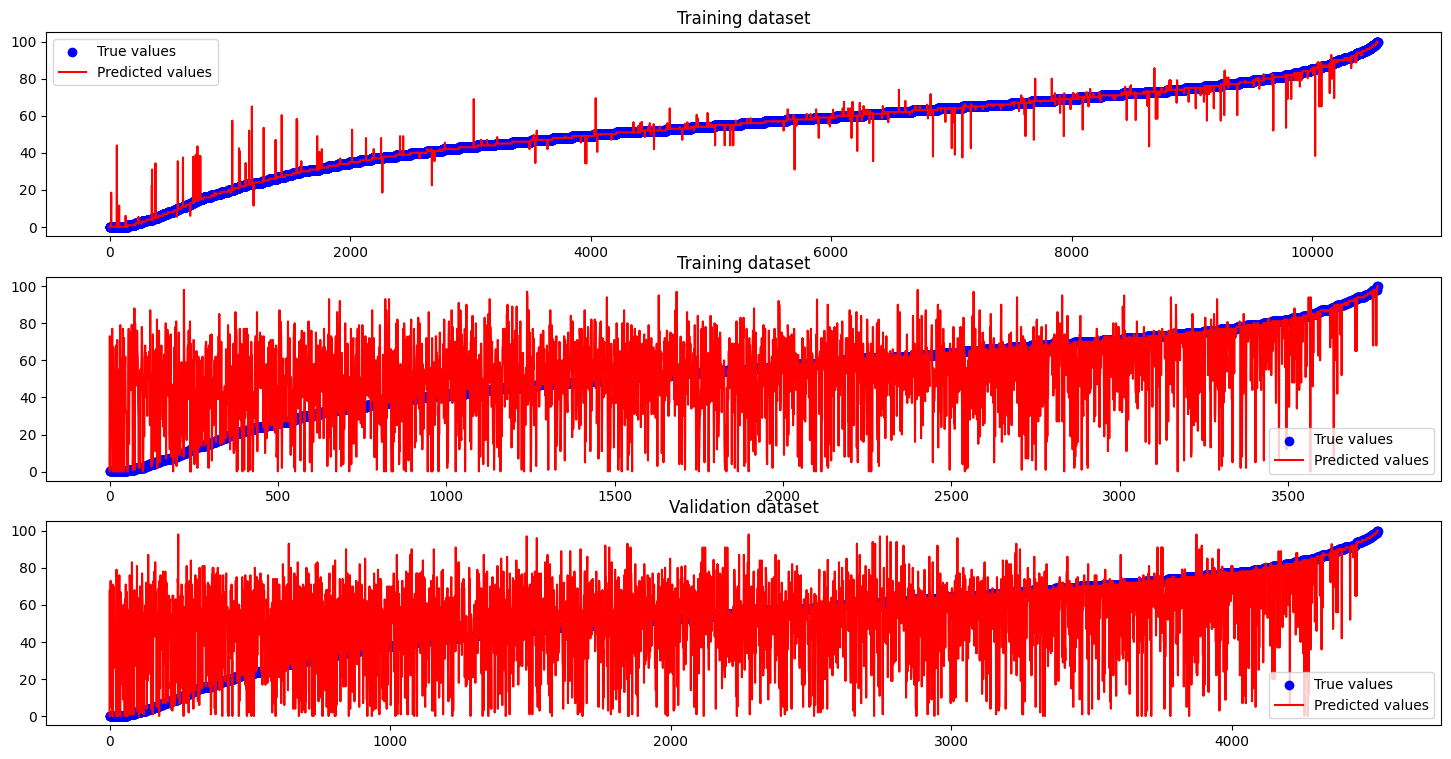

In [97]:
decisionTreeRegressor = dtr(max_depth=30,
                            max_features='log2')
decisionTreeRegressor.fit(X_normalized_dataset['training'], 
                          y_dataset['training'])

y_predicted_training = decisionTreeRegressor.predict(X_normalized_dataset['training'])
y_predicted_test = decisionTreeRegressor.predict(X_normalized_dataset['test'])
y_predicted_valid = decisionTreeRegressor.predict(X_normalized_dataset['validation'])

decistion_tree_predictions = {
    'training'      : y_predicted_training,
    'test'          : y_predicted_test,
    'validation'    : y_predicted_valid
}

resultsDecisionTree = compute_metrics(y_dataset, 
                            decistion_tree_predictions,                    
                            modelName = 'Decision Tree Regressor'
                )

drawPlots(y_dataset, decistion_tree_predictions)



### 2.2.2 - RandomForest

/home/p123/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


--- Training ---
MAE  : 0.15864354049785534
RMSE : 0.26950736243320317
R2   : 0.8758897517136642
MAPE : 0.23147332173583166
--- Test ---
MAE  : 0.42392847945419976
RMSE : 0.7050046265113478
R2   : 0.17521959720178515
MAPE : 0.5969455139499671
--- Validation ---
MAE  : 0.4220189222068092
RMSE : 0.7084531654315152
R2   : 0.1407044282701072
MAPE : 0.6205812612098801


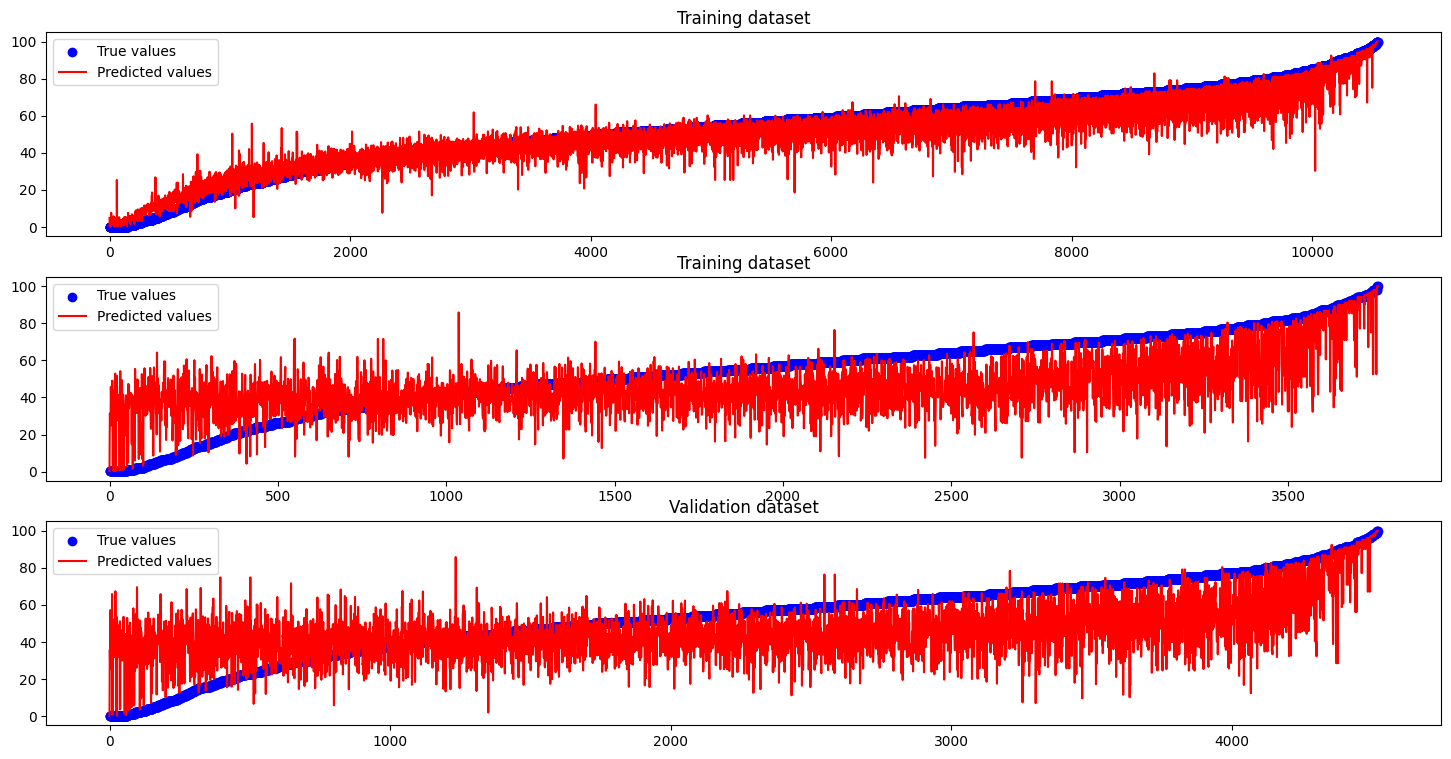

In [ ]:
randomForestRegressor = rfr(n_estimators=100, 
                            max_depth=30)

randomForestRegressor.fit(X_normalized_dataset['training'], 
                          y_dataset['training'])    


y_predicted_training = randomForestRegressor.predict(X_normalized_dataset['training'])
y_predicted_test = randomForestRegressor.predict(X_normalized_dataset['test'])
y_predicted_valid = randomForestRegressor.predict(X_normalized_dataset['validation'])

random_forest_predictions = {
    'training'      : y_predicted_training,
    'test'          : y_predicted_test,
    'validation'    : y_predicted_valid
}

resultsRandomForest = compute_metrics(y_log_dataset, 
                    random_forest_predictions,
                    modelName = 'Random Forest Regressor'
                )

#exponential_predictions = {
#    'training'      : np.expm1(random_forest_predictions['training']),
#    'test'          : np.expm1(random_forest_predictions['test']),
#    'validation'    : np.expm1(random_forest_predictions['validation'])
#}

drawPlots(y_dataset, random_forest_predictions)





### 2.2.3 - Regressao polinomial

#### Transformação de variaveis

In [111]:
## feature transform 
degree = 5
pfTransform     = pf(degree = degree, include_bias=False)

# treina a trasformacao com os dados de treino
pfTransform.fit(X_normalized_dataset['training'])

X_poly_dataset  = {}

X_poly_dataset['training']  = pfTransform.transform(X_normalized_dataset['training'])
X_poly_dataset['test']      = pfTransform.transform(X_normalized_dataset['test'])
X_poly_dataset['validation']= pfTransform.transform(X_normalized_dataset['validation'])

print(f'Numero de features originais: {X_normalized_dataset["training"].shape[1]}')
print(f'Numero de features polinomiais (grau={degree}): {X_poly_dataset["training"].shape[1]}')


Numero de features originais: 13
Numero de features polinomiais (grau=5): 8567


quanto maior o grau da equação, maior a quantidade de novas features a serem treinadas como lr, o que eleva muito o custo computacional de treinamento. 

Também a tendencia a overfitting neste dataset é extremamente elevada. 


### Treinamento do modelo

--- Training ---
MAE  : 7.40349977333602
RMSE : 11.481029346105977
R2   : 0.7242456665747194
MAPE : 2.2304578709168363
--- Test ---
MAE  : 10555871628.0571
RMSE : 83731892307.36049
R2   : -1.4399292949860661e+19
MAPE : 4565073858.278742
--- Validation ---
MAE  : 11546657025.169455
RMSE : 106606195719.88535
R2   : -2.3800219054990328e+19
MAPE : 1579909489.2986088


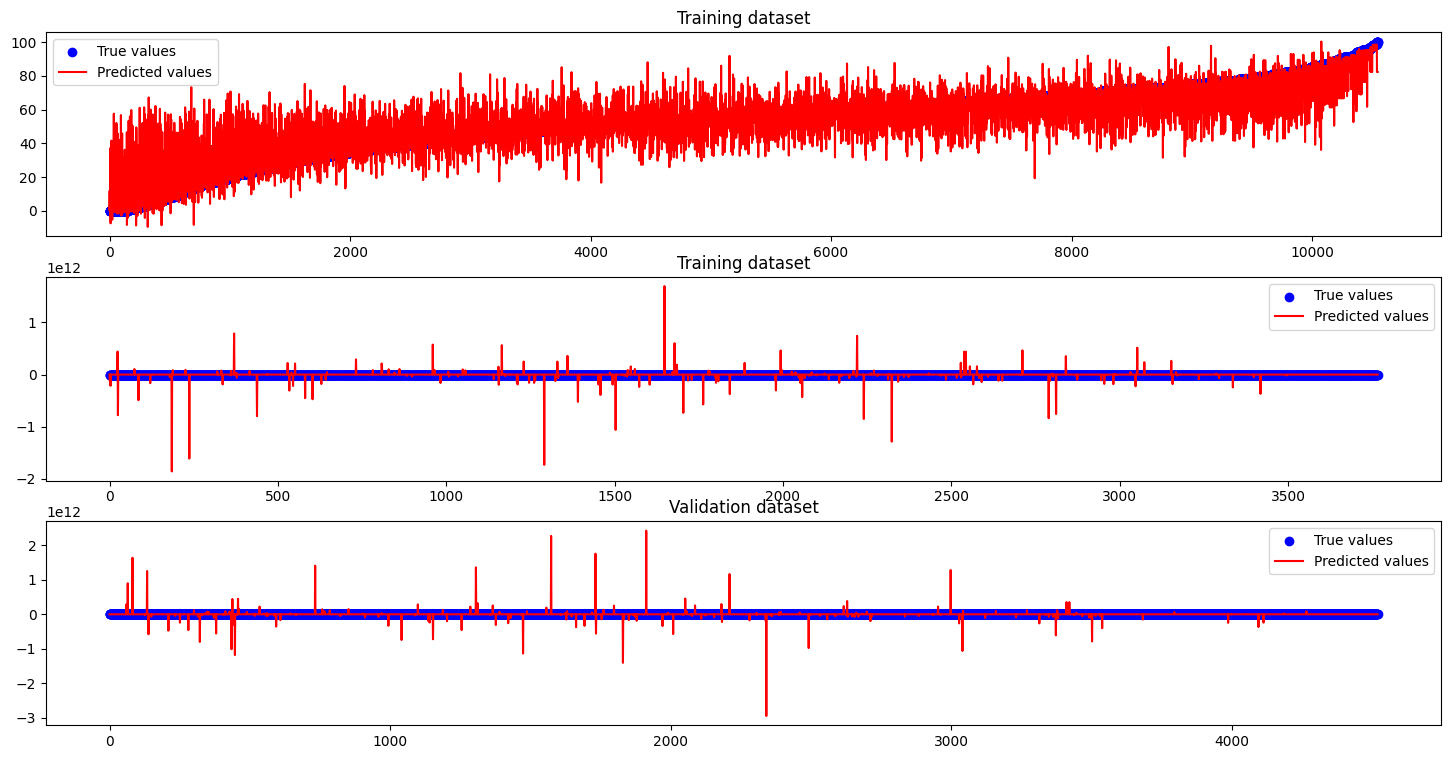

In [112]:
polynomialRegressor = lr()
polynomialRegressor.fit(X_poly_dataset['training'], 
                        y_dataset['training'])

y_predicted_training = polynomialRegressor.predict(X_poly_dataset['training'])
y_predicted_test = polynomialRegressor.predict(X_poly_dataset['test'])
y_predicted_validation = polynomialRegressor.predict(X_poly_dataset['validation'])

polynomial_predictions = {
    'training'      : y_predicted_training,
    'test'          : y_predicted_test,
    'validation'    : y_predicted_validation
}

resultsPolynomial = compute_metrics(y_dataset, 
                        polynomial_predictions,
                        modelName = 'Polynomial Regression'
                )

drawPlots(y_dataset, polynomial_predictions)

A regressão polinomial tende a "explodir" algumas previsões a depender do grau. Quanto maior o grau da regressão, maior a tendencia a explosão
